<a href="https://colab.research.google.com/github/anjipandey16/CaseStudies/blob/main/notebook/EDA_FeatureEngg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np # library for numerical operations
import pandas as pd # library for data manipulation and analysis
import pydotplus # library for creating and displaying graphs from dot files
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Image # class for displaying images in IPython environment



In [ ]:
def read_file():
  input_file = pd.read_csv("/content/sample_data/SynthBank-Fraud v1.0.csv")
  return input_file


In [ ]:
input_file = read_file()

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

## label Encoding of Categorical feature
def label_encoding(input_file,parameter):
  le = LabelEncoder()
  return le.fit_transform(input_file[parameter])


## one hot encoding of a categorical feature
def one_hot_encoding(input_file,parameter):
  ohe = OneHotEncoder()
  return ohe.fit_transform(input_file[parameter])



input_file['merchant_category'] = label_encoding(input_file,'merchant_category')
input_file['channel'] = label_encoding(input_file,'channel')


input_file['timestamp']=pd.to_datetime(input_file['timestamp'])
transaction_date = input_file['timestamp'].dt.month
input_file['t_day'] = input_file['timestamp'].dt.day
input_file['t_month'] = input_file['timestamp'].dt.month
input_file['t_year'] = input_file['timestamp'].dt.year
input_file['t_time'] = input_file['timestamp'].dt.time
input_file.head()


,txn_id,timestamp,user_id,amount,merchant_category,channel,is_fraud,t_day,t_month,t_year,t_time
0,1,2023-01-01 09:05:00,183,18.91,5,3,0,1,1,2023,09:05:00
1,2,2023-01-01 09:15:00,220,33.49,7,0,0,1,1,2023,09:15:00
2,3,2023-01-01 09:15:00,460,18.82,4,3,0,1,1,2023,09:15:00
3,4,2023-01-01 09:27:00,256,38.09,0,3,0,1,1,2023,09:27:00
4,5,2023-01-01 09:28:00,102,45.11,1,2,0,1,1,2023,09:28:00


In [40]:
## after normalization calculating features correlation
def correlation_Cal(input_file):
 return input_file.select_dtypes('number').corr()

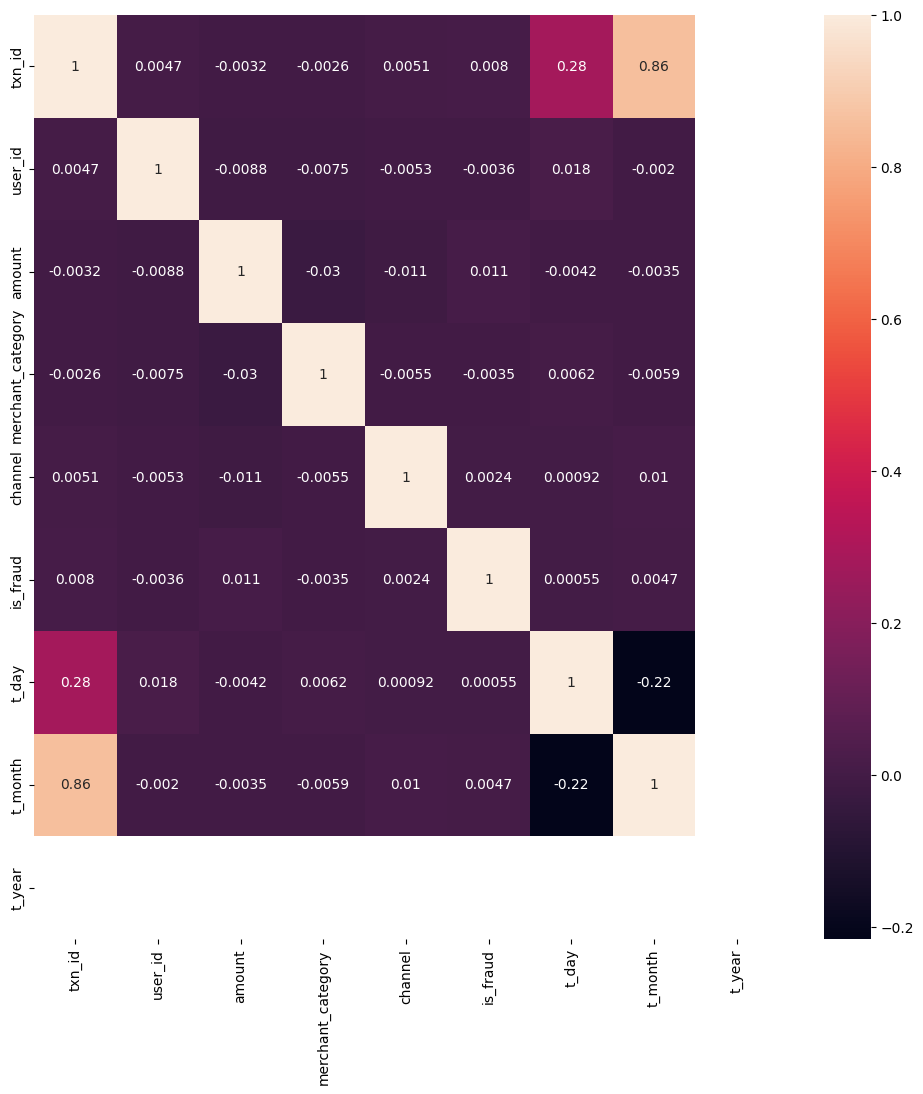

In [41]:
## correlation matrix
plt.figure(figsize=(12, 12))
sns.heatmap(correlation_Cal(input_file), annot=True)
plt.show()

In [38]:

## Histogram chart function
def show_Histogram(input_file,plt,param1,param2,kind,color,title,xlabel,ylabel):
  input_file.groupby(param1)[param2].sum().plot(kind=kind,color=color)
  plt.title(title)
  plt.xlabel(xlabel)
  plt.ylabel(ylabel)
  plt.show()

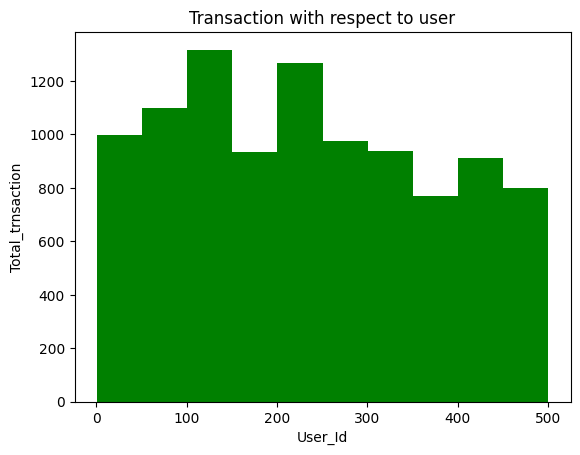

In [39]:
## Histogram Chart for Transaction with respect to user
show_Histogram(input_file,plt,"txn_id","user_id","hist","green","Transaction with respect to user","User_Id","Total_trnsaction")

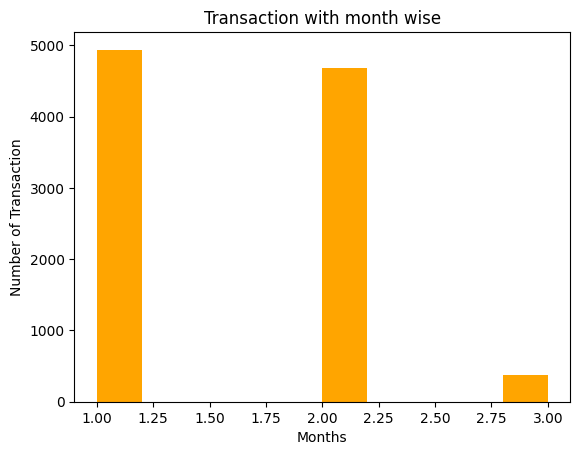

In [36]:
## Histogram chart for Transaction with month wise
show_Histogram(input_file,plt,"txn_id","t_month","hist","orange","Transaction with month wise","Months","Number of Transaction")

In [ ]:
# 2. Group by user and calculate the sum
user_totals = input_file.groupby('user_id')['amount'].sum().sort_values(ascending=True)

# 3. Create the plot
plt.figure(figsize=(20,10))
user_totals.plot(kind='bar', color='white', edgecolor='red')

# 4. Customize the chart
plt.title('Total Amount Spent per User', fontsize=14)
plt.xlabel('User ID')
plt.ylabel('Total Amount ($)')
#plt.xticks(rotation=50)
#plt.grid(axis='y', linestyle='--', alpha=0.7)

# 5. Display
#plt.tight_layout()
plt.show()